<a href="https://colab.research.google.com/github/zanebeeai/mit-sgi-crisscross/blob/main/01_data_preparation_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stanford Bunny data preparation

Normalize, repair, slice, voxelize, and save one reproducible benchmark.
Adapted from https://github.com/haimsaw/OReX/blob/main/Slicer.py.

In [2]:
%pip install -q trimesh rtree shapely gpytoolbox meshcut polyscope


Note: you may need to restart the kernel to use updated packages.


In [3]:
from collections import Counter
from pathlib import Path

import gpytoolbox as gpy
import matplotlib.pyplot as plt
import numpy as np
import trimesh
from matplotlib.path import Path as MplPath
from meshcut import cross_section

SEED = 7 # to randomize planes
GRID_SIZE = 64 # 64^3
N_SLICES = 6
GRID_MIN, GRID_MAX = -1.0, 1.0
ROOT = Path(".") if Path("models").is_dir() else Path("mit-sgi-crisscross")
SOURCE = ROOT / "models/bunny.obj"
OUTPUT = ROOT / "data/bunny_cross_sections.npz"
POLYSCOPE_IMAGE = OUTPUT.parent / "bunny_polyscope.png"

rng = np.random.default_rng(SEED)

## Load, repair, and normalize

In [4]:
def boundary_loops(faces):
    directed = np.vstack((faces[:, [0, 1]], faces[:, [1, 2]], faces[:, [2, 0]]))
    counts = Counter(map(tuple, np.sort(directed, axis=1)))
    boundary = [tuple(edge) for edge in directed if counts[tuple(sorted(edge))] == 1]
    outgoing = {}
    for start, end in boundary:
        if start in outgoing:
            raise ValueError("Non-manifold boundary")
        outgoing[start] = end
    loops = []
    while outgoing:
        start = next(iter(outgoing))
        loop = [start]
        current = start
        while current in outgoing:
            current = outgoing.pop(current)
            if current == start:
                break
            loop.append(current)
        if current != start:
            raise ValueError("Open boundary")
        loops.append(np.asarray(loop, dtype=np.int64))
    return loops


def close_mesh(mesh):
    if mesh.is_watertight:
        return mesh.copy(), []
    loops = boundary_loops(mesh.faces)
    vertices = mesh.vertices.tolist()
    faces = mesh.faces.tolist()
    for loop in loops:
        center = len(vertices)
        vertices.append(mesh.vertices[loop].mean(axis=0))
        for i, start in enumerate(loop):
            faces.append([loop[(i + 1) % len(loop)], start, center])
    repaired = trimesh.Trimesh(np.asarray(vertices), np.asarray(faces), process=True)
    if not repaired.is_watertight:
        raise ValueError("Mesh repair did not produce a watertight surface")
    return repaired, loops


mesh = trimesh.load(SOURCE, force="mesh", process=True)
mesh, repaired_loops = close_mesh(mesh)
mesh.apply_translation(-mesh.bounds.mean(axis=0))
mesh.apply_scale(1.8 / np.ptp(mesh.vertices, axis=0).max())

print({
    "vertices": len(mesh.vertices),
    "faces": len(mesh.faces),
    "repaired_boundaries": [len(loop) for loop in repaired_loops],
    "watertight": mesh.is_watertight,
    "bounds": mesh.bounds.round(3).tolist(),
})

{'vertices': 2507, 'faces': 5010, 'repaired_boundaries': [12, 11, 8, 11], 'watertight': True, 'bounds': [[-0.9, -0.891, -0.698], [0.9, 0.891, 0.698]]}


## Ground-truth 3D SDF

In [5]:
axis = np.linspace(GRID_MIN, GRID_MAX, GRID_SIZE)
grid = np.stack(np.meshgrid(axis, axis, axis, indexing="ij"), axis=-1)
points = grid.reshape(-1, 3) # flatten to list of query points

sdf3d, _, _ = gpy.signed_distance(points, mesh.vertices, mesh.faces)
sdf3d = sdf3d.reshape((GRID_SIZE,) * 3).astype(np.float32)
inside = sdf3d < 0

print({"shape": sdf3d.shape, "inside_voxels": int(inside.sum()), "range": [float(sdf3d.min()), float(sdf3d.max())]})

{'shape': (64, 64, 64), 'inside_voxels': 36581, 'range': [-0.4651715159416199, 1.2066959142684937]}


## Random cross-sections and 2D SDFs

In [ ]:
def plane_frame(normal):
    reference = np.eye(3)[np.argmin(np.abs(normal))]
    u = np.cross(normal, reference)
    u /= np.linalg.norm(u)
    v = np.cross(normal, u)
    return np.column_stack((u, v))


def sample_sections(mesh, count, rng):
    sections = []
    attempts = 0
    while len(sections) < count and attempts < 100:
        attempts += 1
        normal = rng.normal(size=3)
        normal /= np.linalg.norm(normal)
        projection = mesh.vertices @ normal
        position = rng.uniform(np.quantile(projection, 0.15), np.quantile(projection, 0.85))
        origin = normal * position
        loops = cross_section(mesh.vertices, mesh.faces, origin, normal)
        loops = [np.asarray(loop) for loop in loops if len(loop) >= 3]
        if not loops:
            continue
        loops = [loop if np.allclose(loop[0], loop[-1]) else np.vstack((loop, loop[0])) for loop in loops]
        sections.append({"normal": normal, "offset": -position, "origin": origin, "loops": loops})
    if len(sections) != count:
        raise RuntimeError("Could not sample enough non-empty sections")
    return sections


def signed_in_plane_distance(query, section):
    frame = plane_frame(section["normal"])
    query2d = (query - section["origin"]) @ frame
    distance = np.full(len(query), np.inf)
    inside2d = np.zeros(len(query), dtype=bool)
    for loop3d in section["loops"]:
        loop2d = (loop3d[:-1] - section["origin"]) @ frame
        loop_distance, _, _ = gpy.signed_distance(query2d, loop2d)
        distance = np.minimum(distance, np.abs(loop_distance))
        closed = np.vstack((loop2d, loop2d[0]))
        inside2d ^= MplPath(closed).contains_points(query2d)
    return np.where(inside2d, -distance, distance)


sections = sample_sections(mesh, N_SLICES, rng)
plane_normals = np.stack([section["normal"] for section in sections])
plane_offsets = np.asarray([section["offset"] for section in sections])
plane_origins = np.stack([section["origin"] for section in sections])

sdf2d_flat = np.stack([signed_in_plane_distance(points, section) for section in sections]).astype(np.float32)
plane_distance_flat = points @ plane_normals.T + plane_offsets
plane_distance_flat = plane_distance_flat.T.astype(np.float32)
voxel_width = (GRID_MAX - GRID_MIN) / (GRID_SIZE - 1)
slice_mask_flat = np.abs(plane_distance_flat) <= 0.5 * voxel_width

nearest = np.argmin(np.abs(plane_distance_flat), axis=0)
column = np.arange(len(points))
observed_flat = slice_mask_flat.any(axis=0)
observed_sdf2d_flat = np.where(observed_flat, sdf2d_flat[nearest, column], 0.0)
observed_normal_flat = plane_normals[nearest].T * observed_flat

contour_vertices = []
contour_edges = []
contour_plane = []
for plane_id, section in enumerate(sections):
    for loop in section["loops"]:
        loop = loop[:-1]
        start = len(contour_vertices)
        contour_vertices.extend(loop)
        contour_edges.extend([[start + i, start + (i + 1) % len(loop)] for i in range(len(loop))])
        contour_plane.extend([plane_id] * len(loop))

contour_vertices = np.asarray(contour_vertices)
contour_edges = np.asarray(contour_edges, dtype=np.int32)
contour_plane = np.asarray(contour_plane, dtype=np.int16)
distance_squared, _, _ = gpy.squared_distance(points, contour_vertices, contour_edges, use_cpp=True)
u_obs = np.sqrt(np.maximum(distance_squared, 0.0)).reshape((GRID_SIZE,) * 3).astype(np.float32)

sdf2d = sdf2d_flat.reshape((N_SLICES,) + (GRID_SIZE,) * 3)
plane_distance = plane_distance_flat.reshape((N_SLICES,) + (GRID_SIZE,) * 3)
slice_mask = slice_mask_flat.reshape((N_SLICES,) + (GRID_SIZE,) * 3)
observed_mask = observed_flat.reshape((GRID_SIZE,) * 3)
observed_sdf2d = observed_sdf2d_flat.reshape((GRID_SIZE,) * 3).astype(np.float32)
observed_normal = observed_normal_flat.reshape((3,) + (GRID_SIZE,) * 3).astype(np.float32)

## Save benchmark

In [ ]:
from IPython.display import FileLink, display

OUTPUT.parent.mkdir(parents=True, exist_ok=True)
np.savez_compressed(
    OUTPUT,
    seed=np.int64(SEED),
    grid_axis=axis.astype(np.float32),
    vertices=mesh.vertices.astype(np.float32),
    faces=mesh.faces.astype(np.int32),
    sdf3d=sdf3d,
    inside=inside,
    plane_normals=plane_normals.astype(np.float32),
    plane_offsets=plane_offsets.astype(np.float32),
    plane_origins=plane_origins.astype(np.float32),
    plane_distance=plane_distance,
    slice_mask=slice_mask,
    sdf2d=sdf2d,
    observed_mask=observed_mask,
    observed_sdf2d=observed_sdf2d,
    observed_normal=observed_normal,
    u_obs=u_obs,
    contour_vertices=contour_vertices.astype(np.float32),
    contour_edges=contour_edges,
    contour_plane=contour_plane,
)

print(f"{OUTPUT} ({OUTPUT.stat().st_size / 2**20:.1f} MiB)")
display(FileLink(str(OUTPUT)))


/content/mit-sgi-crisscross/data/bunny_cross_sections.npz (13.1 MiB)


/content/mit-sgi-crisscross/data/bunny_cross_sections.npz

## Checks

In [ ]:
sample_ids = rng.choice(len(points), size=5000, replace=False)
max_plane_violation = 0.0
for plane_id, section in enumerate(sections):
    projected = points[sample_ids] - plane_distance_flat[plane_id, sample_ids, None] * section["normal"]
    projected_sdf, _, _ = gpy.signed_distance(projected, mesh.vertices, mesh.faces)
    violation = np.abs(projected_sdf) - np.abs(sdf2d_flat[plane_id, sample_ids])
    max_plane_violation = max(max_plane_violation, float(violation.max()))

assert mesh.is_watertight
assert slice_mask_flat.any(axis=1).all()
assert max_plane_violation < 1e-4

print({
    "slices": N_SLICES,
    "loops_per_slice": [len(section["loops"]) for section in sections],
    "observed_voxels": int(observed_mask.sum()),
    "max_sampled_bound_violation": max_plane_violation,
})

{'slices': 6, 'loops_per_slice': [1, 1, 1, 1, 2, 1], 'observed_voxels': 24973, 'max_sampled_bound_violation': 1.333284121995959e-09}


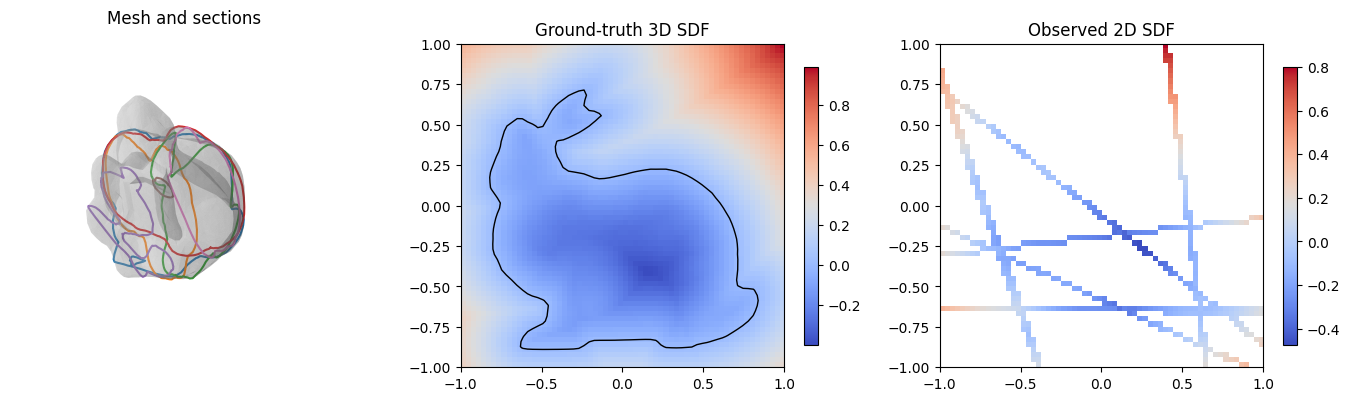

In [ ]:
middle = GRID_SIZE // 2
fig = plt.figure(figsize=(14, 4))

ax = fig.add_subplot(1, 3, 1, projection="3d")
ax.plot_trisurf(*mesh.vertices.T, triangles=mesh.faces, color="#b8b8b8", alpha=0.25, linewidth=0)
for section in sections:
    for loop in section["loops"]:
        ax.plot(*loop.T, linewidth=1.5)
ax.set_box_aspect((1, 1, 1))
ax.set_title("Mesh and sections")
ax.set_axis_off()

ax = fig.add_subplot(1, 3, 2)
image = ax.imshow(sdf3d[:, :, middle].T, origin="lower", extent=[GRID_MIN, GRID_MAX] * 2, cmap="coolwarm")
ax.contour(axis, axis, sdf3d[:, :, middle].T, levels=[0], colors="black", linewidths=1)
ax.set_title("Ground-truth 3D SDF")
fig.colorbar(image, ax=ax, shrink=0.8)

ax = fig.add_subplot(1, 3, 3)
shown = np.where(observed_mask[:, :, middle], observed_sdf2d[:, :, middle], np.nan)
image = ax.imshow(shown.T, origin="lower", extent=[GRID_MIN, GRID_MAX] * 2, cmap="coolwarm")
ax.set_title("Observed 2D SDF")
fig.colorbar(image, ax=ax, shrink=0.8)

fig.tight_layout()
plt.show()

## Cross Section SDFs

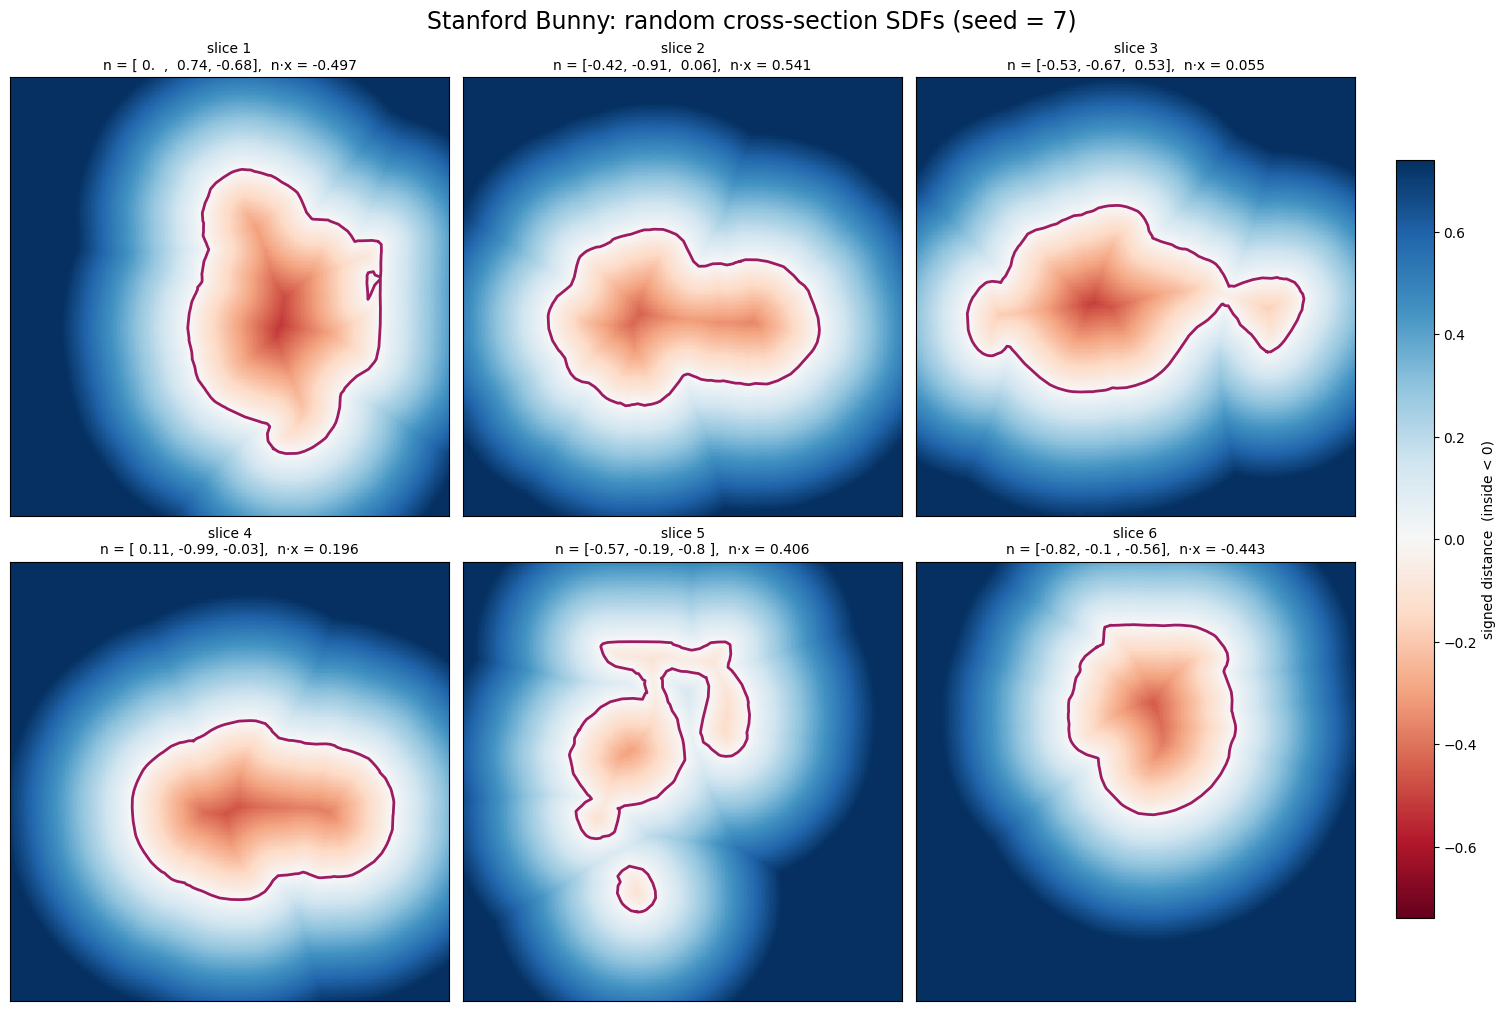

Saved data/bunny_slice_sdfs.png


In [ ]:
from matplotlib.colors import TwoSlopeNorm

SDF_PLOT_GRID_SIZE = 320
SDF_PLOT_PADDING = 0.15
SDF_COLOR_QUANTILE = 0.80
SLICE_SDF_IMAGE = OUTPUT.parent / "bunny_slice_sdfs.png"

local_sections = [
    (f := plane_frame(s["normal"]), [(l[:-1] - s["origin"]) @ f for l in s["loops"]])
    for s in sections
]
all_loop_points = np.vstack([lp for _, loops2d in local_sections for lp in loops2d])

plot_center = 0.5 * (all_loop_points.min(axis=0) + all_loop_points.max(axis=0))
plot_half_width = np.ptp(all_loop_points, axis=0).max() * (0.5 + SDF_PLOT_PADDING)

plot_space = lambda c: np.linspace(c - plot_half_width, c + plot_half_width, SDF_PLOT_GRID_SIZE)
X2D, Y2D = np.meshgrid(plot_space(plot_center[0]), plot_space(plot_center[1]))
query2d = np.c_[X2D.ravel(), Y2D.ravel()]

slice_sdf_images = [
    signed_in_plane_distance(s["origin"] + query2d @ f.T, s).reshape(X2D.shape)
    for s, (f, _) in zip(sections, local_sections)
]
color_limit = max(float(np.quantile(np.abs(slice_sdf_images), SDF_COLOR_QUANTILE)), np.finfo(float).eps)
color_norm = TwoSlopeNorm(vmin=-color_limit, vcenter=0.0, vmax=color_limit)

figure, axes = plt.subplots(2, 3, figsize=(15, 10), constrained_layout=True)
image_artist = None

for slice_id, (ax, section, (_, loops2d), image_sdf) in enumerate(
    zip(axes.flatten(), sections, local_sections, slice_sdf_images), start=1
):
    image_artist = ax.pcolormesh(
        X2D, Y2D, np.clip(image_sdf, -color_limit, color_limit),
        shading="auto", cmap="RdBu", norm=color_norm
    )
    for loop2d in loops2d:
        ax.plot(*np.vstack([loop2d, loop2d[0]]).T, color="#9c1b63", linewidth=2.0)
    n_str = np.array2string(section["normal"], precision=2, separator=", ", suppress_small=True)
    ax.set_title(f"slice {slice_id}\nn = {n_str},  n·x = {section['normal'] @ section['origin']:.3f}", fontsize=10)
    ax.set(aspect="equal", xticks=[], yticks=[])

figure.colorbar(image_artist, ax=axes.flatten(), shrink=0.82, pad=0.03, label="signed distance  (inside < 0)")
figure.suptitle(f"Stanford Bunny: random cross-section SDFs (seed = {SEED})", fontsize=17)

figure.savefig(SLICE_SDF_IMAGE, dpi=220, facecolor="white")
plt.show()
plt.close(figure)
print(f"Saved {SLICE_SDF_IMAGE}")

## Polyscope visualization

The translucent surface lets contours on the far side remain visible. Each
slicing plane has its own color.


Saved /content/mit-sgi-crisscross/data/bunny_polyscope_contours.png


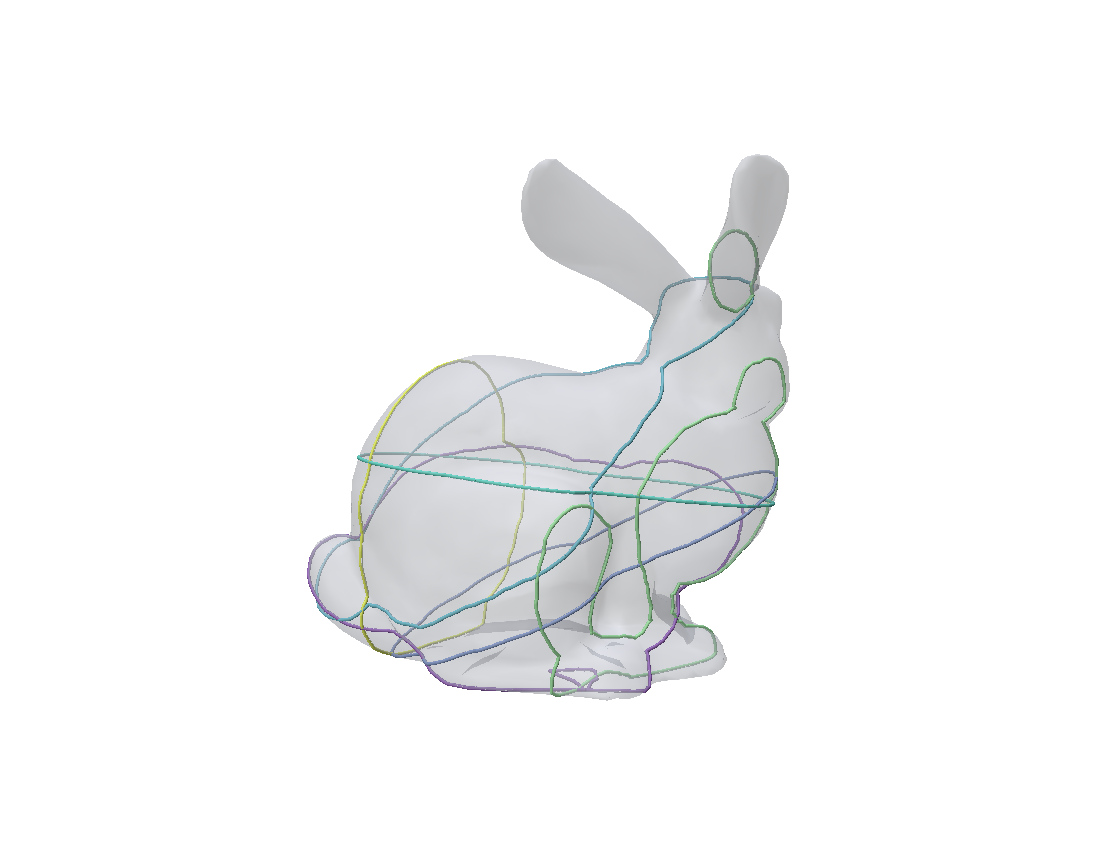

In [ ]:
import os
import polyscope as ps
from IPython.display import Image, display


def section_curve_network(section):
    nodes = []
    edges = []
    vertex_offset = 0
    for closed_loop in section["loops"]:
        loop = np.asarray(closed_loop[:-1], dtype=float)
        if len(loop) < 3:
            continue
        indices = np.arange(len(loop), dtype=np.int32) + vertex_offset
        nodes.append(loop)
        edges.append(np.column_stack((indices, np.roll(indices, -1))))
        vertex_offset += len(loop)
    if not nodes:
        return None, None
    return np.vstack(nodes), np.vstack(edges).astype(np.int32)


ps.set_allow_headless_backends(True)
ps.init("openGL3_egl")
ps.remove_all_structures()
ps.set_window_size(1100, 850)
ps.set_up_dir("y_up")
ps.set_front_dir("neg_z_front")
ps.set_ground_plane_mode("none")
ps.set_background_color((1.0, 1.0, 1.0))

bunny_ps = ps.register_surface_mesh(
    "Stanford Bunny",
    mesh.vertices,
    mesh.faces,
    smooth_shade=True,
)
bunny_ps.set_color((0.72, 0.74, 0.78))
bunny_ps.set_transparency(0.42)
ps.set_transparency_mode("pretty")

slice_colors = plt.get_cmap("viridis")(
    np.linspace(0.08, 0.92, len(sections))
)
for slice_id, (section, rgba) in enumerate(
    zip(sections, slice_colors), start=1
):
    nodes, edges = section_curve_network(section)
    if nodes is None:
        continue
    curve = ps.register_curve_network(
        f"slice {slice_id}",
        nodes,
        edges,
    )
    curve.set_color(tuple(rgba[:3]))
    curve.set_radius(0.006, relative=False)

ps.reset_camera_to_home_view()
POLYSCOPE_IMAGE.parent.mkdir(parents=True, exist_ok=True)
ps.screenshot(str(POLYSCOPE_IMAGE), transparent_bg=False)

print(f"Saved {POLYSCOPE_IMAGE}")
display(Image(filename=str(POLYSCOPE_IMAGE)))


Data Visualization

NameError: name 'ps' is not defined